In [4]:
import pandas as pd
from scipy.stats import zscore
df = pd.read_csv(
    r"C:\Users\91934\OneDrive\Desktop\DA\ZDIP\data\cleaned\cleaned_movies.csv"
)


#### Outlier Analysis (IQR Method)

In [5]:
columns = ["Revenue", "Genre_Count", "Production_Company_Count"]

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, len(outliers))

Revenue 387
Genre_Count 188
Production_Company_Count 167


#### Outlier Analysis (Z-score Method)

In [6]:
from scipy.stats import zscore

for col in columns:
    df[f"{col}_zscore"] = zscore(df[col])

    outliers = df[abs(df[f"{col}_zscore"]) > 3]

    print(col, len(outliers))

Revenue 0
Genre_Count 13
Production_Company_Count 52


#### Distribution Chart (Histogram)

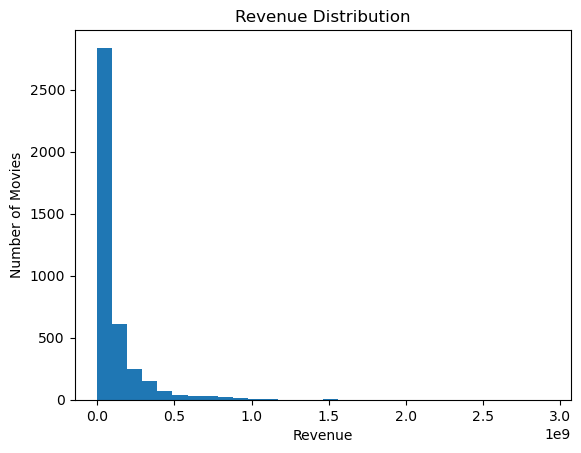

In [7]:
import matplotlib.pyplot as plt

plt.hist(df["Revenue"], bins=30)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of Movies")

plt.show()

#### Trend Chart (Revenue by Year)

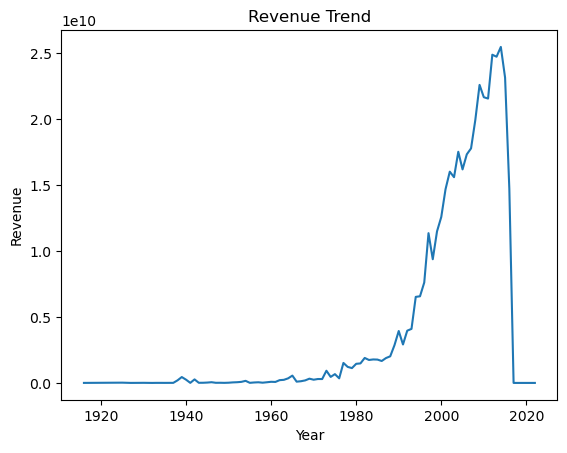

In [8]:
revenue_trend = df.groupby("Release_Year")["Revenue"].sum()

plt.plot(
    revenue_trend.index,
    revenue_trend.values
)

plt.title("Revenue Trend")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.show()

#### Comparison Chart (Top 10 Production Companies)

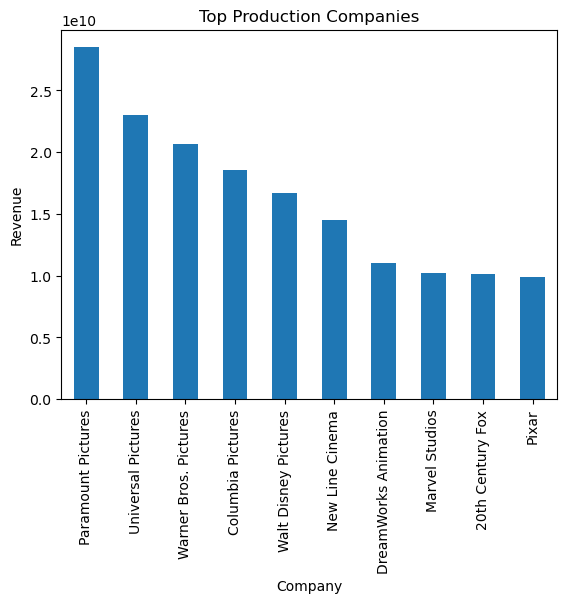

In [9]:
top_companies = (
    df.groupby("Primary_Production_Company")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_companies.plot(kind="bar")

plt.title("Top Production Companies")
plt.xlabel("Company")
plt.ylabel("Revenue")

plt.show()

#### Composition Chart (Genre Share)

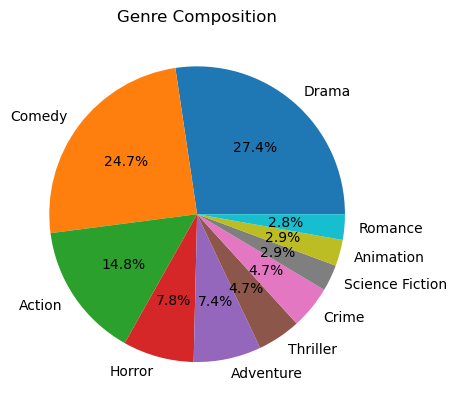

In [10]:
genre_share = df["Primary_Genre"].value_counts().head(10)

genre_share.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Genre Composition")
plt.ylabel("")

plt.show()

##### Five Dataset-Grounded Insights
- A small number of movies generate extremely high revenue, creating significant outliers.
- Most movies belong to one or two genres, while movies with many genres are rare.
- The majority of movies are produced by a limited number of production companies.
- A few production companies contribute a large share of the total revenue.
- Revenue distribution is highly right-skewed because blockbuster movies dominate the dataset.